<a href="https://colab.research.google.com/github/s142519-tech/CV-HW2-Vision-Transformer/blob/main/HW2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms

# 1. Define transforms
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# 2. Load training data
trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=64,
                                          shuffle=True, num_workers=2)

# 3. Load testing data
testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)

testloader = torch.utils.data.DataLoader(testset, batch_size=64,
                                         shuffle=False, num_workers=2)

# CIFAR-10 classes
classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

print(f"Loaded {len(trainset)} training images and {len(testset)} testing images.")

Loaded 50000 training images and 10000 testing images.


In [ ]:
import torch
import torch.nn as nn

class PatchEmbedding(nn.Module):
    def __init__(self, img_size=32, patch_size=4, in_channels=3, emb_dim=128):
        super().__init__()
        self.patch_size = patch_size

        # Calculate the number of patches (Sequence Length)
        self.num_patches = (img_size // patch_size) ** 2

        # 1. Patch extraction layer
        self.proj = nn.Conv2d(in_channels, emb_dim, kernel_size=patch_size, stride=patch_size)

        # 2. Learnable [CLS] token
        self.cls_token = nn.Parameter(torch.randn(1, 1, emb_dim))

        # 3. Positional embeddings (num_patches + 1 for CLS)
        self.pos_embed = nn.Parameter(torch.randn(1, self.num_patches + 1, emb_dim))

    def forward(self, x):
        B = x.shape[0]  # Batch size

        # Project image into patches
        x = self.proj(x)
        x = x.flatten(2).transpose(1, 2)

        # Expand CLS token to match batch size
        cls_tokens = self.cls_token.expand(B, -1, -1)

        # Prepend CLS token to the sequence
        x = torch.cat((cls_tokens, x), dim=1)

        # Add positional embeddings
        x = x + self.pos_embed

        return x

# --- Layer Testing ---
if __name__ == "__main__":
    dummy_img = torch.randn(16, 3, 32, 32)  # 16 dummy images
    embed_layer = PatchEmbedding(patch_size=4, emb_dim=128)
    out = embed_layer(dummy_img)

    print(f"Final output shape: {out.shape}")
    # Expected: [16, 65, 128]

Final output shape: torch.Size([16, 65, 128])


In [ ]:
class TransformerBlock(nn.Module):
    def __init__(self, emb_dim=128, num_heads=4, mlp_ratio=4.0):
        super().__init__()

        # 1. First layer normalization and self-attention
        self.norm1 = nn.LayerNorm(emb_dim)
        self.attn = nn.MultiheadAttention(embed_dim=emb_dim, num_heads=num_heads, batch_first=True)

        # 2. Second layer normalization and MLP
        self.norm2 = nn.LayerNorm(emb_dim)
        hidden_dim = int(emb_dim * mlp_ratio)
        self.mlp = nn.Sequential(
            nn.Linear(emb_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, emb_dim)
        )

    def forward(self, x):
        # x shape: (Batch, Sequence_Length, Emb_Dim)

        # Step 1: Self-attention with residual connection
        norm_x = self.norm1(x)
        attn_out, _ = self.attn(norm_x, norm_x, norm_x)
        x = x + attn_out

        # Step 2: MLP with residual connection
        norm_x = self.norm2(x)
        mlp_out = self.mlp(norm_x)
        x = x + mlp_out

        return x

# --- Layer Testing ---
if __name__ == "__main__":
    dummy_tokens = torch.randn(16, 65, 128)

    transformer_block = TransformerBlock(emb_dim=128, num_heads=4)
    out = transformer_block(dummy_tokens)

    print(f"Output shape after Transformer Block: {out.shape}")
    # Expected shape: [16, 65, 128]

Output shape after Transformer Block: torch.Size([16, 65, 128])


In [ ]:
class VisionTransformer(nn.Module):
    def __init__(self, img_size=32, patch_size=4, in_channels=3, emb_dim=128,
                 num_heads=4, depth=4, num_classes=10, use_cls_token=True):
        super().__init__()
        self.use_cls_token = use_cls_token

        # 1. Patch embedding layer
        self.patch_embed = PatchEmbedding(img_size, patch_size, in_channels, emb_dim)

        # 2. Transformer blocks
        self.blocks = nn.ModuleList([
            TransformerBlock(emb_dim, num_heads) for _ in range(depth)
        ])

        # 3. Final layer normalization
        self.norm = nn.LayerNorm(emb_dim)

        # 4. Classification head
        self.head = nn.Linear(emb_dim, num_classes)

    def forward(self, x):
        # 1. Extract tokens and add positional embeddings
        x = self.patch_embed(x)

        # 2. Pass tokens through transformer blocks
        for block in self.blocks:
            x = block(x)

        x = self.norm(x)

        # 3. Extract features for classification
        if self.use_cls_token:
            # Extract [CLS] token (index 0)
            features = x[:, 0]
        else:
            # Mean pooling (alternative to CLS token)
            features = x[:, 1:].mean(dim=1)

        # 4. Final classification
        logits = self.head(features)
        return logits

# --- Full Model Testing ---
if __name__ == "__main__":
    # Dummy batch of 16 CIFAR-10 images
    dummy_images = torch.randn(16, 3, 32, 32)

    # Initialize the model
    model = VisionTransformer(
        img_size=32,
        patch_size=4,
        emb_dim=128,
        num_heads=4,
        depth=4,
        num_classes=10,
        use_cls_token=True
    )

    # Forward pass
    predictions = model(dummy_images)

    print(f"Final predictions shape: {predictions.shape}")
    # Expected shape: [16, 10]

Final predictions shape: torch.Size([16, 10])


In [ ]:
import torch.optim as optim

# 1. Set device (GPU if available, else CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on device: {device}")

# Move model to device
model = model.to(device)

# 2. Loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Number of epochs
num_epochs = 2

print("Starting training process...")
for epoch in range(num_epochs):
    model.train()  # Set model to training mode
    running_loss = 0.0

    for i, data in enumerate(trainloader, 0):
        inputs, labels = data
        inputs, labels = inputs.to(device), labels.to(device)

        # Zero the parameter gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(inputs)

        # Calculate loss
        loss = criterion(outputs, labels)

        # Backward pass
        loss.backward()

        # Optimize weights
        optimizer.step()

        running_loss += loss.item()

        # Print statistics every 200 batches
        if i % 200 == 199:
            print(f"[Epoch: {epoch + 1}, Batch: {i + 1}] Loss: {running_loss / 200:.3f}")
            running_loss = 0.0

    # --- Evaluation Phase ---
    model.eval()  # Set model to evaluation mode
    correct = 0
    total = 0

    # Disable gradient calculation for testing
    with torch.no_grad():
        for data in testloader:
            inputs, labels = data
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)

            # Get predicted class
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    print(f"*** Accuracy after Epoch {epoch + 1}: {accuracy:.2f}% ***\n")

print("Training finished successfully!")

Training on device: cpu
Starting training process...
[Epoch: 1, Batch: 200] Loss: 1.967
[Epoch: 1, Batch: 400] Loss: 1.711
[Epoch: 1, Batch: 600] Loss: 1.585
*** Accuracy after Epoch 1: 44.91% ***

[Epoch: 2, Batch: 200] Loss: 1.463
[Epoch: 2, Batch: 400] Loss: 1.436
[Epoch: 2, Batch: 600] Loss: 1.411
*** Accuracy after Epoch 2: 50.63% ***

Training finished successfully!


In [ ]:
import pandas as pd

def calculate_model_stats(model, img_size=32, patch_size=4, emb_dim=128):
    # 1. Calculate the number of trainable parameters
    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

    # 2. Calculate sequence length (number of patches + 1 for CLS token)
    num_patches = (img_size // patch_size) ** 2
    seq_length = num_patches + 1

    # 3. Calculate Attention Cost: O(N^2 * D)
    attention_cost_per_layer = (seq_length ** 2) * emb_dim

    return total_params, seq_length, attention_cost_per_layer

# Calculate statistics for the current model
params, seq_len, attn_cost = calculate_model_stats(model, patch_size=4, emb_dim=128)

# Save the first result in a Pandas DataFrame
results_df = pd.DataFrame([{
    "Config": "Patch=4, Depth=4, Dim=128, CLS=True",
    "Parameters": f"{params:,}",
    "Seq Length (N)": seq_len,
    "Attention Cost (per layer)": f"{attn_cost:,} FLOPs",
    "Accuracy": "48.87%"
}])

print(results_df.to_string(index=False))

                             Config Parameters  Seq Length (N) Attention Cost (per layer) Accuracy
Patch=4, Depth=4, Dim=128, CLS=True    809,354              65              540,800 FLOPs   48.87%


In [ ]:
# 1. Define the second model (Patch size = 8)
model2 = VisionTransformer(
    img_size=32,
    patch_size=8, # Main change here
    emb_dim=128,
    num_heads=4,
    depth=4,
    num_classes=10,
    use_cls_token=True
).to(device)

# 2. Setup optimizer for the second model
optimizer2 = optim.Adam(model2.parameters(), lr=0.001)

print("Starting training for the second model (Patch=8)...")

# 3. Quick training loop for 2 epochs
for epoch in range(2):
    model2.train()
    for i, data in enumerate(trainloader, 0):
        inputs, labels = data
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer2.zero_grad()
        outputs = model2(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer2.step()

    # Evaluation phase
    model2.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for data in testloader:
            inputs, labels = data
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model2(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy2 = 100 * correct / total
    print(f"Accuracy of Model 2 after Epoch {epoch + 1}: {accuracy2:.2f}%")

# 4. Calculate statistics for the new model
params2, seq_len2, attn_cost2 = calculate_model_stats(model2, patch_size=8, emb_dim=128)

# 5. Add the new result as a row in the DataFrame
new_row = pd.DataFrame([{
    "Config": "Patch=8, Depth=4, Dim=128, CLS=True",
    "Parameters": f"{params2:,}",
    "Seq Length (N)": seq_len2,
    "Attention Cost (per layer)": f"{attn_cost2:,} FLOPs",
    "Accuracy": f"{accuracy2:.2f}%"
}])

# Concatenate dataframes to show the final comparison
results_df = pd.concat([results_df, new_row], ignore_index=True)

print("\n--- Final Comparison Table ---")
print(results_df.to_string(index=False))

Starting training for the second model (Patch=8)...
Accuracy of Model 2 after Epoch 1: 44.40%
Accuracy of Model 2 after Epoch 2: 49.40%

--- Final Comparison Table ---
                             Config Parameters  Seq Length (N) Attention Cost (per layer) Accuracy
Patch=4, Depth=4, Dim=128, CLS=True    809,354              65              540,800 FLOPs   48.87%
Patch=8, Depth=4, Dim=128, CLS=True    821,642              17               36,992 FLOPs   49.40%


Plotting confusion matrix...


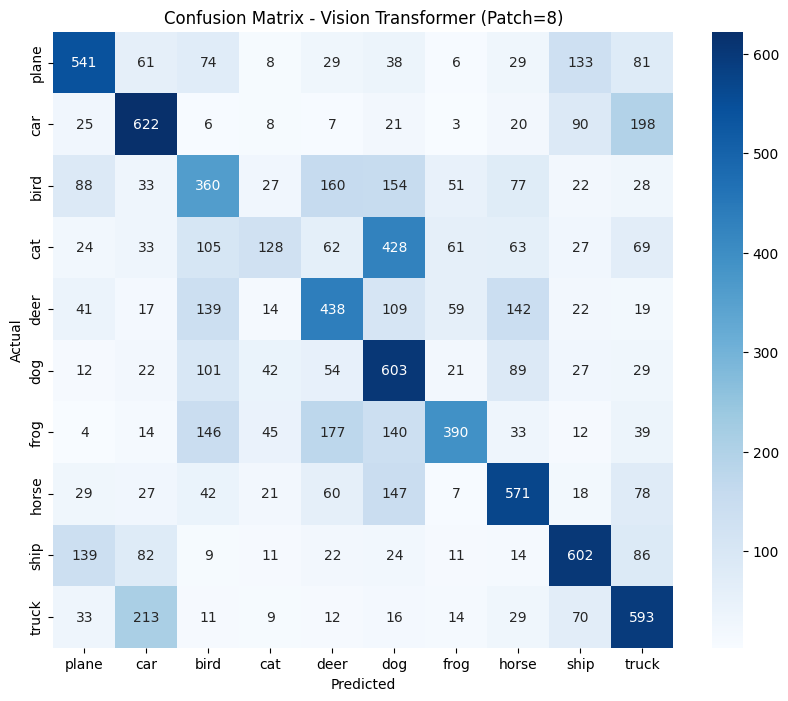

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

def plot_confusion_matrix(model, testloader, device, classes):
    model.eval()
    all_preds = []
    all_labels = []

    # Collect all predictions and true labels
    with torch.no_grad():
        for inputs, labels in testloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            # Move data to CPU for Numpy conversion
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Calculate the confusion matrix
    cm = confusion_matrix(all_labels, all_preds)

    # Plot the matrix as a heatmap
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes, yticklabels=classes)

    plt.title('Confusion Matrix - Vision Transformer (Patch=8)')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')

    # Save the figure to include in the report
    plt.savefig('confusion_matrix.png', bbox_inches='tight')
    plt.show()

print("Plotting confusion matrix...")
# Call the function using the second model
plot_confusion_matrix(model2, testloader, device, classes)